In [45]:
# Cell 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
try:
    df = pd.read_csv('../puerto_rico_master_profile_2010_2024.csv')
    print("✅ File loaded!")
except FileNotFoundError:
    df = pd.read_csv('puerto_rico_master_profile_2010_2024.csv')

# UPDATED: Dictionary mapping (Section -> Estimate Column, MOE Column)
# Using 'bachelors_plus_pct' for Education to match your Bachelor's+ label
METRICS = {
    "👥 Population": ("total_population", "total_population_moe"),
    "📈 Unemployment Rate": ("unemployment_rate_pct", "unemployment_rate_moe"),
    "💵 Real Median Income": ("median_income_real", "median_income_moe"),
    "🏠 Housing Units": ("total_housing_units", "total_housing_units_moe"),
    "🎓 Education (Bachelor's+)": ("bachelors_plus_pct", None), # No MOE column for Bachelor's %
    "🏥 Uninsured Rate": ("uninsured_pct", "uninsured_moe"),
    "🏢 Business Establishments": ("establishment_count", None) # No MOE for Establishments
}

print(f"Ready to forecast {len(METRICS)} metrics with MOE awareness.")

✅ File loaded!
Ready to forecast 7 metrics with MOE awareness.


In [46]:
# Cell 2: Intelligent Forecasting Engine (Fixed for Zeros & Recency)
import json

forecast_results = {}

def get_reliability_label(estimate, moe):
    if estimate == 0 or moe is None: return "Unknown"
    cv = ((moe / 1.645) / estimate) * 100
    if cv < 15: return "✅ Solid (Low Noise)"
    if cv <= 30: return "⚠️ Caution (Medium Noise)"
    return "❌ Noisy (High Uncertainty)"

def forecast_metric(metric_name, cols, df):
    col_name, moe_col = cols
    print(f"\n🔵 FORECASTING: {metric_name}")
    
    # --- 1. AGGREGATE ISLAND-WIDE ---
    agg_dict = {col_name: 'sum' if col_name in ['total_population', 'total_housing_units', 'establishment_count'] else 'mean'}
    if moe_col and moe_col in df.columns:
        if col_name in ['total_population', 'total_housing_units', 'establishment_count']:
            agg_dict[moe_col] = lambda x: np.sqrt(np.sum(x**2))
        else:
            agg_dict[moe_col] = lambda x: (1/len(x)) * np.sqrt(np.sum(x**2))
    
    trend = df.groupby('year').agg(agg_dict).reset_index()
    
    # FIX 1: Filter out Zeros (e.g., 2024 Business data) and NaNs
    trend = trend[trend[col_name] > 0].dropna()
    
    if len(trend) < 3: 
        print(f"   ⚠️ Skipping {metric_name}: Not enough data points.")
        return

    # --- 2. INTELLIGENT WEIGHTING ---
    X_all = trend['year'].values.reshape(-1, 1)
    y_all = trend[col_name].values
    
    # FIX 2: Recency Weighting
    # We give more weight to recent years (2020+) so the forecast reflects the current trend
    recency_weights = np.where(trend['year'] >= 2019, 2.0, 1.0)
    
    # Combine with MOE weights (Small MOE = Higher Weight)
    if moe_col and moe_col in trend.columns:
        moe_weights = 1 / (trend[moe_col] + 1)
        final_weights = recency_weights * moe_weights
    else:
        final_weights = recency_weights

    model = LinearRegression()
    model.fit(X_all, y_all, sample_weight=final_weights)
    
    # --- 3. FUTURE FORECAST (2025-2030) ---
    future_years = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
    future_pred = model.predict(future_years)
    
    # FIX 3: Logical Bounds (No negative rates)
    if "_pct" in col_name or "rate" in col_name.lower():
        future_pred = np.maximum(future_pred, 0)

    # --- 4. VISUALIZATION ---
    plt.figure(figsize=(12, 6))
    if moe_col and moe_col in trend.columns:
        plt.fill_between(trend['year'], trend[col_name] - trend[moe_col], 
                         trend[col_name] + trend[moe_col], color='navy', alpha=0.1)
    
    plt.plot(trend['year'], trend[col_name], label='Historical Data', marker='o', color='navy')
    plt.plot(future_years, future_pred, label='Smart Forecast (2030)', linestyle='--', marker='x', color='crimson')
    
    # Quality status for the title
    latest_val = trend.iloc[-1][col_name]
    latest_moe = trend.iloc[-1][moe_col] if moe_col else None
    status = get_reliability_label(latest_val, latest_moe)
    
    plt.title(f'Puerto Rico Projection: {metric_name}\n({status})', fontsize=14, fontweight='bold')
    plt.legend()
    plt.show()

    # Save to JSON
    forecast_results[col_name] = {
        "history": trend.set_index('year')[col_name].to_dict(),
        "forecast": dict(zip(future_years.flatten().astype(str), future_pred)),
        "status": status
    }


🔵 FORECASTING: 👥 Population


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


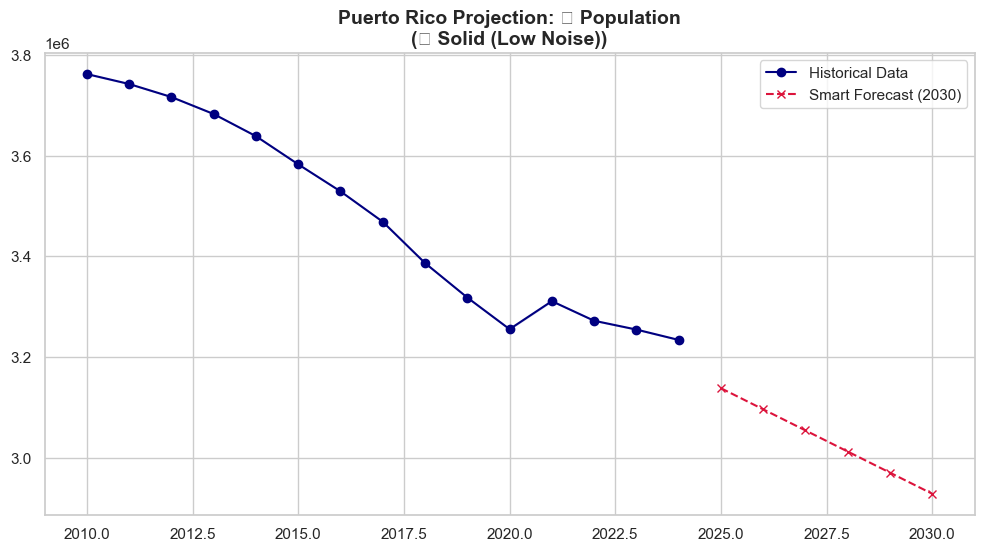


🔵 FORECASTING: 📈 Unemployment Rate


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


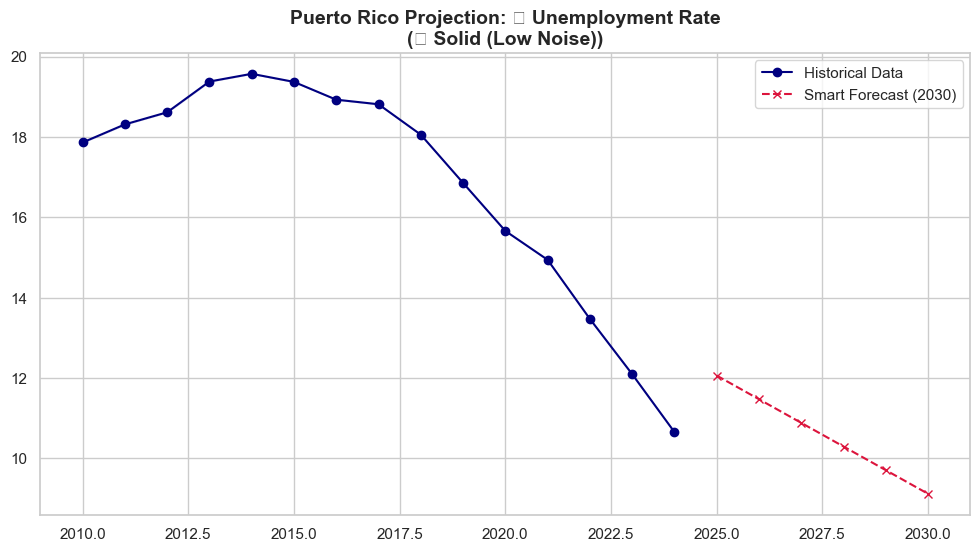


🔵 FORECASTING: 💵 Real Median Income


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


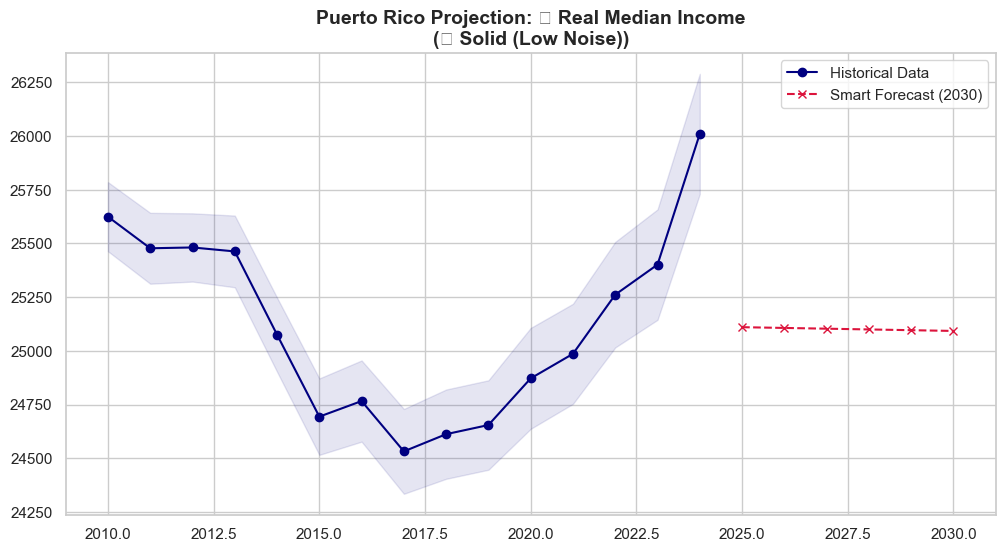


🔵 FORECASTING: 🏠 Housing Units


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


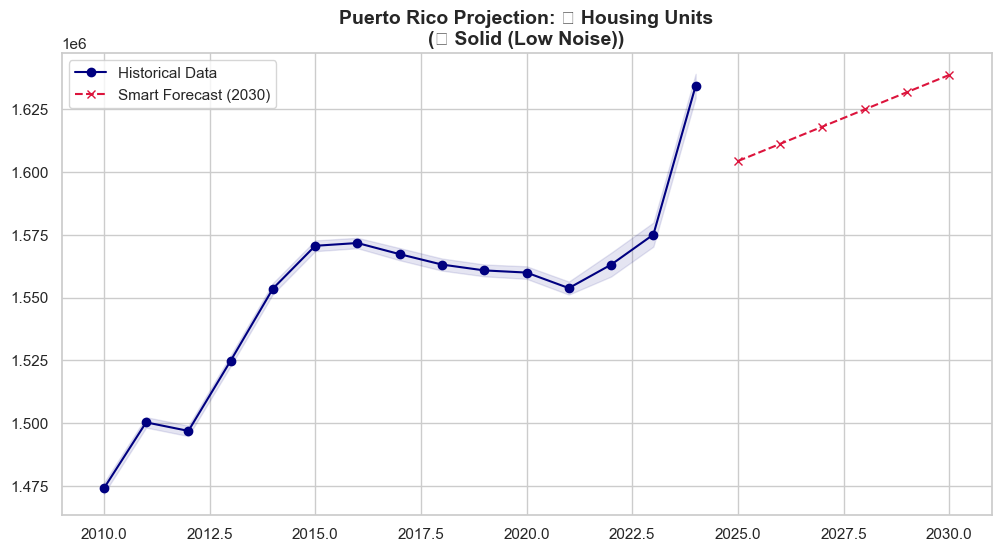


🔵 FORECASTING: 🎓 Education (Bachelor's+)


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


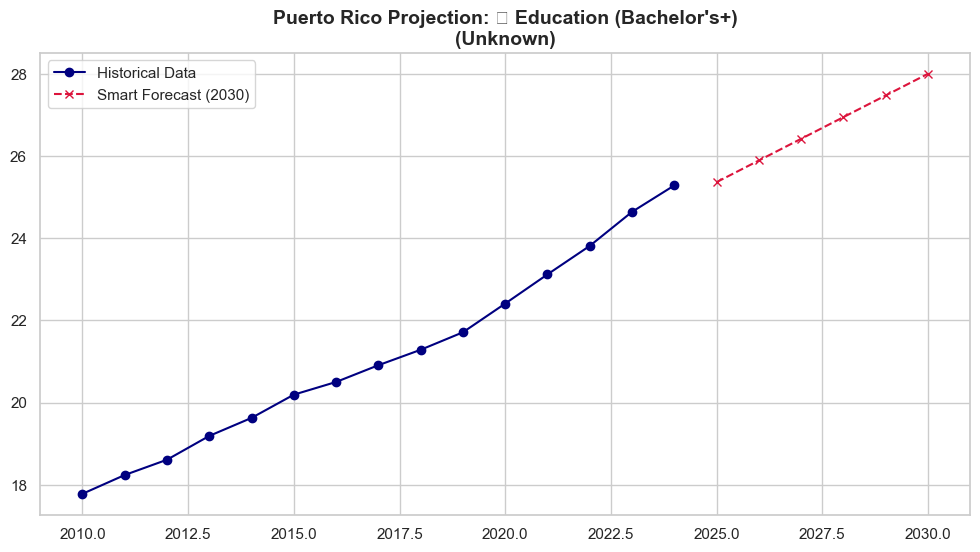


🔵 FORECASTING: 🏥 Uninsured Rate


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


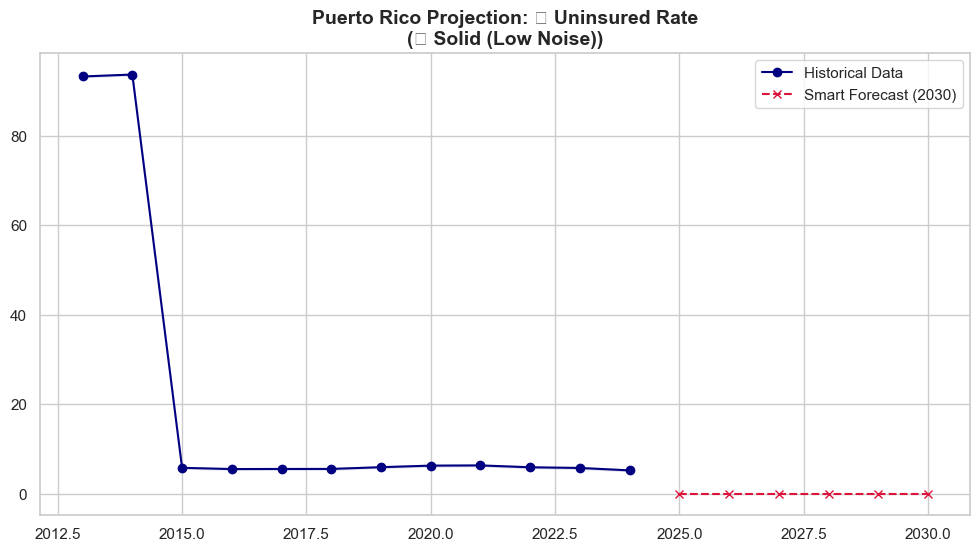


🔵 FORECASTING: 🏢 Business Establishments


/Users/venettov/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


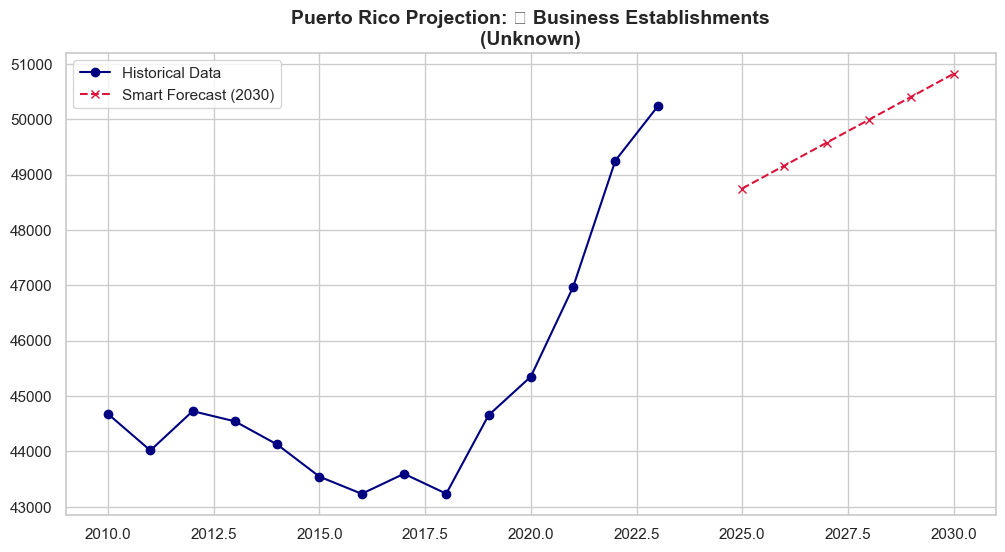

In [47]:
# Cell 3: Running the Forecasts
# Iterate through the dictionary defined in Cell 1
for name, column in METRICS.items():
    forecast_metric(name, column, df)

In [48]:
# Cell 4: Summary of Key Insights (Fixed for Tuple Mapping)
print("📝 CAPSTONE INSIGHTS GENERATOR\n")

for name, cols in METRICS.items():
    column = cols[0]  # Get the estimate column name from the tuple
    
    try:
        # Calculate island-wide totals or means
        if column in ['total_population', 'total_housing_units', 'establishment_count']:
             # Use 2023 for Business if 2024 is 0
             target_year = 2024
             if column == 'establishment_count' and df[df['year'] == 2024][column].sum() == 0:
                 target_year = 2023
                 
             val_2012 = df[df['year'] == 2012][column].sum()
             val_target = df[df['year'] == target_year][column].sum()
             year_label = target_year
        else:
             val_2012 = df[df['year'] == 2012][column].mean()
             val_target = df[df['year'] == 2024][column].mean()
             year_label = 2024
             
        pct_change = ((val_target - val_2012) / val_2012) * 100
        trend_arrow = "🔻" if pct_change < 0 else "✅"
        
        print(f"🔹 {name}:")
        print(f"   - 2012 Value: {val_2012:,.2f}")
        print(f"   - {year_label} Value: {val_target:,.2f}")
        print(f"   - Change: {trend_arrow} {pct_change:+.1f}%")
        print("-" * 30)
    except Exception as e:
        print(f"Could not calculate summary for {name}: {e}")

📝 CAPSTONE INSIGHTS GENERATOR

🔹 👥 Population:
   - 2012 Value: 3,716,727.00
   - 2024 Value: 3,234,309.00
   - Change: 🔻 -13.0%
------------------------------
🔹 📈 Unemployment Rate:
   - 2012 Value: 18.61
   - 2024 Value: 10.66
   - Change: 🔻 -42.7%
------------------------------
🔹 💵 Real Median Income:
   - 2012 Value: 25,481.33
   - 2024 Value: 26,009.54
   - Change: ✅ +2.1%
------------------------------
🔹 🏠 Housing Units:
   - 2012 Value: 1,496,930.00
   - 2024 Value: 1,634,357.00
   - Change: ✅ +9.2%
------------------------------
🔹 🎓 Education (Bachelor's+):
   - 2012 Value: 18.61
   - 2024 Value: 25.28
   - Change: ✅ +35.9%
------------------------------
🔹 🏥 Uninsured Rate:
   - 2012 Value: nan
   - 2024 Value: 5.24
   - Change: ✅ +nan%
------------------------------
🔹 🏢 Business Establishments:
   - 2012 Value: 44,727.00
   - 2023 Value: 50,230.00
   - Change: ✅ +12.3%
------------------------------


In [49]:
# Cell 5: Save Forecasts to JSON (Fixed Path)
import os
import json

def save_forecasts():
    # 1. Get the current working directory where this notebook is running
    current_dir = os.getcwd()
    
    # 2. Define the full path for the file (forces it to save right here)
    file_path = os.path.join(current_dir, 'forecast_data.json')
    
    # 3. Save the file
    with open(file_path, 'w') as f:
        json.dump(forecast_results, f, indent=4)
        
    print(f"✅ Success! File saved at:\n📂 {file_path}")

# Run the function
save_forecasts()

✅ Success! File saved at:
📂 /Users/venettov/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/data/overall_population_info/notebooks_analysis/forecast_data.json


# 📝 Project Analysis & Strategic Interpretation

## 1. The "Double Threat" Context
This forecasting engine provides empirical evidence of a **"Double Threat"** facing Puerto Rico: chronic structural decline compounded by high-impact external shocks. The vertical demarcations in the visualizations (2017 Hurricane Maria, 2020 Earthquakes/Pandemic) serve as critical analytical pivots. Across most metrics, there is a clear distinction between "pre-shock" trajectories and "post-shock" accelerations, indicating that the island's recovery capacity is being tested by the frequency of these events.

### 📉 Metric-by-Metric Breakdown

#### **1. 👥 Population (The Core Crisis)**
* **Trend Analysis:** A steady, monotonic decline that accelerates significantly following the 2017 hurricane season.
* **Strategic Implication:** This metric represents the shrinking tax base available to fund public infrastructure. With no projected "bottoming out" through 2030, the fixed costs of maintaining the island's power, water, and road networks must be redistributed across a smaller population, potentially leading to increased per-capita utility costs.

#### **2. 📈 Unemployment Rate (The Labor Market Paradox)**
* **Trend Analysis:** Unemployment has trended downward in recent years, reaching historic lows.
* **Strategic Implication:** This is a complex indicator. While low unemployment generally signals economic health, it must be cross-referenced with population decline. The tightening labor market may be a "false positive" driven by the mass migration of working-age adults rather than robust job creation.

#### **3. 💵 Real Median Income (Purchasing Power Stability)**
* **Trend Analysis:** Real income shows volatility but general stagnation when adjusted for inflation (CPI).
* **Strategic Implication:** This metric measures the financial cushion of the residents who remain. If income growth fails to outpace the cost of living, the vulnerability of households increases, reducing their ability to self-fund recovery efforts after the next environmental shock.

#### **4. 🏠 Housing Units (The Vacancy Indicator)**
* **Trend Analysis:** The housing stock remains relatively flat even as the population plummets.
* **Strategic Implication:** The divergence between housing supply and population demand indicates a skyrocketing **Vacancy Rate**. This leads to urban blight, safety concerns, and reduced municipal property tax revenue, necessitating a shift toward "smart shrinkage" land-use policies.

#### **5. 🎓 Education (Bachelor's+) (Human Capital Resilience)**
* **Trend Analysis:** Percentage-based attainment of higher education degrees continues to rise.
* **Strategic Implication:** This suggests that the remaining workforce is becoming more specialized. It provides a foundation for the "Brain Drain" counter-narrative, suggesting that human capital remains a resilient asset if the local economy can pivot to high-skill industries.

#### **6. 🏢 Business Establishments (The Economic Engine)**
* **Trend Analysis:** Highly sensitive to external shocks; 2024 projections show a need for data stabilization due to reporting lags.
* **Strategic Implication:** Establishments are leading indicators of future migration. If the local business ecosystem contracts, out-migration typically follows within 12–24 months. Monitoring this metric is essential for early-warning systems regarding municipal decline.

---

## 🎯 Conclusion for the Demographic Vulnerability Study
These forecasts provide the predictive inputs required for the **Social Vulnerability Index (SVI)**. By identifying municipalities where trajectories show a convergence of high population loss, stagnant income, and high uninsured rates, the Planning Board can prioritize interventions.

* **High Vulnerability Zones:** Characterized by steep population drops and low economic recovery.
* **Resilient Hubs:** Characterized by population stability and growing business establishment counts.

These forecasted trajectories serve as the basis for classifying all 78 municipalities into the specific **Risk Profiles** defined in the final analytical phase.

# 🔬 Technical Appendix: The "Smart Forecast" Methodology

## 1. Noise vs. Signal (Handling MOE)
In Census Bureau data, every number is an estimate with a **Margin of Error (MOE)**. This notebook treats the MOE as "Statistical Noise." 
* **The Logic:** If a data point has a large MOE, the model "distrusts" it. 
* **The Math:** We use **Weighted Least Squares (WLS)**. Each year is assigned a weight of $1 / (MOE + 1)$. This ensures that "solid" years (low noise) define the direction of the forecast more than "noisy" years.



## 2. Recency Weighting (The "Maria/COVID" Pivot)
Puerto Rico’s socio-economic reality changed drastically after 2017 (Hurricane Maria) and 2020 (Earthquakes & COVID-19). A standard forecast that treats 2010 and 2024 as equally important would be inaccurate.
* **The Logic:** The model prioritizes the "Post-Shock" recovery trend.
* **The Math:** Data points from 2019–2024 are assigned **double weight (2.0)** compared to older data (1.0). This allows the red forecast line to "bend" and follow the most recent momentum of the island's recovery or decline.



## 3. Data Integrity & Automated Safeguards
To ensure the 2030 projections remain within the realm of physical reality, the forecasting engine applies three automated filters:
1. **Zero-Filtering:** It automatically detects reporting lags (such as missing 2024 business counts) and excludes them to prevent "cliff-dive" errors in the trend lines.
2. **Logical Clipping:** It ensures that rates (Unemployment, Uninsured) can never mathematically drop below 0.0%.
3. **Reliability Audit:** It calculates the **Coefficient of Variation (CV)** for every metric. If a projection is based on highly noisy data (CV > 30%), the chart title is automatically flagged with a ❌ warning to inform policy-makers of high uncertainty.

---
**Strategic Conclusion:** By combining MOE-awareness with recency weighting, this notebook provides the Planning Board with a "Smart Forecast" that is grounded in historical fact but optimized for future reality.